In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path


In [7]:
# Ruta relativa: funciona si cwd es el proyecto o la carpeta notebooks
ruta_pkl = Path.cwd() / 'datos' / 'intermedios' / 'tablon_analitico.pkl'
if not ruta_pkl.exists():
    ruta_pkl = Path.cwd().parent / 'datos' / 'intermedios' / 'tablon_analitico.pkl'
df = pd.read_pickle(ruta_pkl)

In [ ]:
# por si lo queremos leer sin usar el Path.cwd()
df = pd.read_pickle('../datos/intermedios/tablon_analitico.pkl')

In [9]:
ruta_pkl

WindowsPath('c:/Users/Usuario/Desktop/PDSM/02_BUSINESS_ANALYTICS/09_CASO_2_PLANTA_SOLAR/PROYECTO_PLANTA_SOLAR/datos/intermedios/tablon_analitico.pkl')

In [10]:
df.head()

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2
0,2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,sensor_p1,25.184316,22.857507,0.0
1,2020-05-15,p1,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,sensor_p1,25.184316,22.857507,0.0
2,2020-05-15,p1,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,sensor_p1,25.184316,22.857507,0.0
3,2020-05-15,p1,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,sensor_p1,25.184316,22.857507,0.0
4,2020-05-15,p1,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,sensor_p1,25.184316,22.857507,0.0


In [11]:
# Extraer componentes de fecha_hora: mes, año, día y time
df['mes'] = df['fecha_hora'].dt.month
df['dia'] = df['fecha_hora'].dt.day
df['hora'] = df['fecha_hora'].dt.hour
df['minuto'] = df['fecha_hora'].dt.minute
df['time'] = df['fecha_hora'].dt.time

In [12]:
df

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2,mes,dia,hora,minuto,time
0,2020-05-15 00:00:00,p1,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,sensor_p1,25.184316,22.857507,0.0,5,15,0,0,00:00:00
1,2020-05-15 00:00:00,p1,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,sensor_p1,25.184316,22.857507,0.0,5,15,0,0,00:00:00
2,2020-05-15 00:00:00,p1,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,sensor_p1,25.184316,22.857507,0.0,5,15,0,0,00:00:00
3,2020-05-15 00:00:00,p1,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,sensor_p1,25.184316,22.857507,0.0,5,15,0,0,00:00:00
4,2020-05-15 00:00:00,p1,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,sensor_p1,25.184316,22.857507,0.0,5,15,0,0,00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136471,2020-06-17 23:45:00,p2,q49J1IKaHRwDQnt,0.0,0.0,4157.0,520758.0,sensor_p2,23.202871,22.535908,0.0,6,17,23,45,23:45:00
136472,2020-06-17 23:45:00,p2,rrq4fwE8jgrTyWY,0.0,0.0,3931.0,121131356.0,sensor_p2,23.202871,22.535908,0.0,6,17,23,45,23:45:00
136473,2020-06-17 23:45:00,p2,vOuJvMaM2sgwLmb,0.0,0.0,4322.0,2427691.0,sensor_p2,23.202871,22.535908,0.0,6,17,23,45,23:45:00
136474,2020-06-17 23:45:00,p2,xMbIugepa2P7lBB,0.0,0.0,4218.0,106896394.0,sensor_p2,23.202871,22.535908,0.0,6,17,23,45,23:45:00


In [13]:
#pasar fecha_hora a índice
df.set_index('fecha_hora', inplace=True)

In [15]:
df.head()

,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2,mes,dia,hora,minuto,time
fecha_hora,,,,,,,,,,,,,,,
2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,sensor_p1,25.184316,22.857507,0.0,5,15,0,0,00:00:00
2020-05-15,p1,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,sensor_p1,25.184316,22.857507,0.0,5,15,0,0,00:00:00
2020-05-15,p1,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,sensor_p1,25.184316,22.857507,0.0,5,15,0,0,00:00:00
2020-05-15,p1,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,sensor_p1,25.184316,22.857507,0.0,5,15,0,0,00:00:00
2020-05-15,p1,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,sensor_p1,25.184316,22.857507,0.0,5,15,0,0,00:00:00


CREACIÓN VARIABLES

In [22]:
def eficiencia(dc,ac):
    temp = np.where(dc>0, ac/dc, 1)*100
    return np.where(temp>100,100,temp)

In [23]:
df['eficiencia'] = eficiencia(df['potencia_dc_kw'], df['potencia_ac_kw'])
df.tail()

,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2,mes,dia,hora,minuto,time,eficiencia
fecha_hora,,,,,,,,,,,,,,,,
2020-06-17 23:45:00,p2,q49J1IKaHRwDQnt,0.0,0.0,4157.0,520758.0,sensor_p2,23.202871,22.535908,0.0,6,17,23,45,23:45:00,100.0
2020-06-17 23:45:00,p2,rrq4fwE8jgrTyWY,0.0,0.0,3931.0,121131356.0,sensor_p2,23.202871,22.535908,0.0,6,17,23,45,23:45:00,100.0
2020-06-17 23:45:00,p2,vOuJvMaM2sgwLmb,0.0,0.0,4322.0,2427691.0,sensor_p2,23.202871,22.535908,0.0,6,17,23,45,23:45:00,100.0
2020-06-17 23:45:00,p2,xMbIugepa2P7lBB,0.0,0.0,4218.0,106896394.0,sensor_p2,23.202871,22.535908,0.0,6,17,23,45,23:45:00,100.0
2020-06-17 23:45:00,p2,xoJJ8DcxJEcupym,0.0,0.0,4316.0,209335741.0,sensor_p2,23.202871,22.535908,0.0,6,17,23,45,23:45:00,100.0


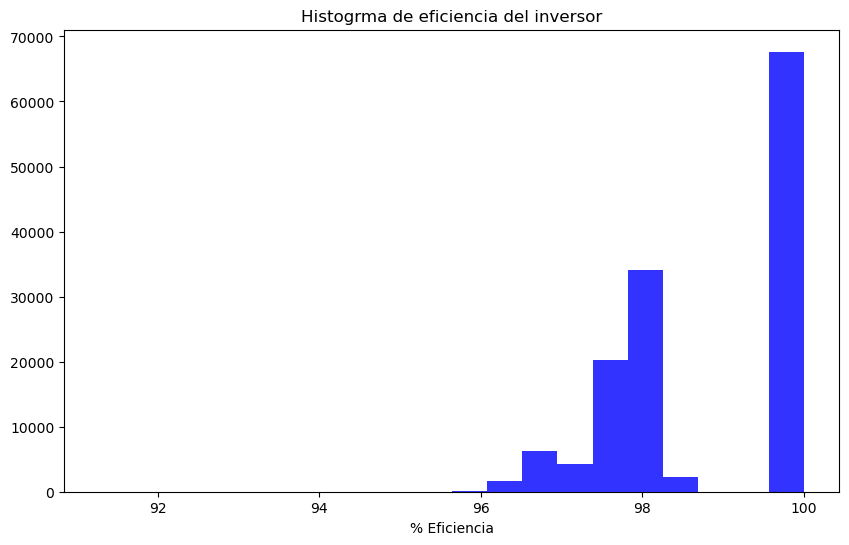

In [27]:
# Histograma de eficiencias
plt.figure(figsize=(10,6))
plt.hist(df['eficiencia'], bins=20, color='blue', alpha=0.8)
plt.title("Histogrma de eficiencia del inversor")
plt.xlabel("% Eficiencia");

ORDEN DE LAS VARIABLES LÓGICO DENTRO DEL DATASET

In [28]:
df.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 136472 entries, 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_planta                136472 non-null  object 
 1   id_inversor              136472 non-null  str    
 2   potencia_dc_kw           136472 non-null  float64
 3   potencia_ac_kw           136472 non-null  float64
 4   energia_diaria_kwh       136472 non-null  float64
 5   energia_total_kwh        136472 non-null  float64
 6   id_sensor_meteorologico  136472 non-null  str    
 7   temperatura_ambiente_c   136472 non-null  float64
 8   temperatura_modulo_c     136472 non-null  float64
 9   irradiacion_wh_m2        136472 non-null  float64
 10  mes                      136472 non-null  int32  
 11  dia                      136472 non-null  int32  
 12  hora                     136472 non-null  int32  
 13  minuto                   136472 non-

In [30]:
orden = ['id_planta', 'id_inversor','id_sensor_meteorologico','mes','dia','time','hora','minuto','irradiacion_wh_m2','temperatura_ambiente_c','temperatura_modulo_c','potencia_dc_kw','potencia_ac_kw','eficiencia','energia_diaria_kwh','energia_total_kwh']
df = df[orden]
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 136472 entries, 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_planta                136472 non-null  object 
 1   id_inversor              136472 non-null  str    
 2   id_sensor_meteorologico  136472 non-null  str    
 3   mes                      136472 non-null  int32  
 4   dia                      136472 non-null  int32  
 5   time                     136472 non-null  object 
 6   hora                     136472 non-null  int32  
 7   minuto                   136472 non-null  int32  
 8   irradiacion_wh_m2        136472 non-null  float64
 9   temperatura_ambiente_c   136472 non-null  float64
 10  temperatura_modulo_c     136472 non-null  float64
 11  potencia_dc_kw           136472 non-null  float64
 12  potencia_ac_kw           136472 non-null  float64
 13  eficiencia               136472 non-

In [31]:
df

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,potencia_ac_kw,eficiencia,energia_diaria_kwh,energia_total_kwh
fecha_hora,,,,,,,,,,,,,,,,
2020-05-15 00:00:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,0.0,100.0,0.0,6259559.0
2020-05-15 00:00:00,p1,1IF53ai7Xc0U56Y,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,0.0,100.0,0.0,6183645.0
2020-05-15 00:00:00,p1,3PZuoBAID5Wc2HD,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,0.0,100.0,0.0,6987759.0
2020-05-15 00:00:00,p1,7JYdWkrLSPkdwr4,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,0.0,100.0,0.0,7602960.0
2020-05-15 00:00:00,p1,McdE0feGgRqW7Ca,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,0.0,100.0,0.0,7158964.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-17 23:45:00,p2,q49J1IKaHRwDQnt,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,0.0,100.0,4157.0,520758.0
2020-06-17 23:45:00,p2,rrq4fwE8jgrTyWY,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,0.0,100.0,3931.0,121131356.0
2020-06-17 23:45:00,p2,vOuJvMaM2sgwLmb,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,0.0,100.0,4322.0,2427691.0


NIVEL DE AGREGACIÓN DIARIO

In [35]:
df_dia = df.groupby(['id_planta','id_inversor']).resample('D').agg(
    {'irradiacion_wh_m2': ['min','mean','max','sum'],
    'temperatura_ambiente_c': ['min','mean','max'],
    'temperatura_modulo_c': ['min','mean','max'],
    'potencia_dc_kw': ['min','mean','max'],
    'potencia_ac_kw': ['min','mean','max'],
    'eficiencia':  ['min','mean','max'],
    'energia_diaria_kwh': ['min','mean','max'],
    'energia_total_kwh': ['min','mean','max'],
    }
)
df_dia.head()

irradiacion_wh_m2                      \
                                                   min      mean       max   
id_planta id_inversor     fecha_hora                                         
p1        1BY6WEcLGh8j5v7 2020-05-15               0.0  0.204699  0.893661   
                          2020-05-16               0.0  0.211951  0.812241   
                          2020-05-17               0.0  0.238869  0.997904   
                          2020-05-18               0.0  0.159026  0.971481   
                          2020-05-19               0.0  0.194031  0.835832   

                                                temperatura_ambiente_c  \
                                            sum                    min   
id_planta id_inversor     fecha_hora                                     
p1        1BY6WEcLGh8j5v7 2020-05-15  19.037010              22.037482   
                          2020-05-16  18.651690              21.496287   
                          2020-05-17  22.931378              21.209418   
                          2020-05-18  15.266485              20.961525   
                          2020-05-19  18.044861              22.388784   

                                                            \
                                           mean        max   
id_planta id_inversor     fecha_hora                         
p1        1BY6WEcLGh8j5v7 2020-05-15  27.430823  34.430943   
                          2020-05-16  26.780538  32.524149   
                          2020-05-17  26.686727  35.252486   
                          2020-05-18  23.850938  28.367100   
                          2020-05-19  25.338021  30.368632   

                                     temperatura_modulo_c             \
                                                      min       mean   
id_planta id_inversor     fecha_hora                                   
p1        1BY6WEcLGh8j5v7 2020-05-15            20.290726  32.582964   
                          2020-05-16            19.592692  31.858851   
                          2020-05-17            20.377121  32.740435   
                          2020-05-18            19.477531  27.814344   
                          2020-05-19            20.062144  29.725163   

                                                 ... potencia_ac_kw  \
                                            max  ...            max   
id_planta id_inversor     fecha_hora             ...                  
p1        1BY6WEcLGh8j5v7 2020-05-15  55.030613  ...    1039.350000   
                          2020-05-16  54.232746  ...    1095.285714   
                          2020-05-17  63.145582  ...    1114.814286   
                          2020-05-18  53.936739  ...    1193.628571   
                          2020-05-19  51.847742  ...    1059.800000   

                                     eficiencia                    \
                                            min       mean    max   
id_planta id_inversor     fecha_hora                                
p1        1BY6WEcLGh8j5v7 2020-05-15  96.350365  98.816849  100.0   
                          2020-05-16  96.521739  98.732919  100.0   
                          2020-05-17  96.416185  98.837466  100.0   
                          2020-05-18  96.605431  98.856972  100.0   
                          2020-05-19  96.556671  98.977423  100.0   

                                     energia_diaria_kwh                       \
                                                    min         mean     max   
id_planta id_inversor     fecha_hora                                           
p1        1BY6WEcLGh8j5v7 2020-05-15                0.0  2641.120776  5754.0   
                          2020-05-16                0.0  3380.406047  6292.0   
                          2020-05-17                0.0  3473.035714  7045.0   
                          2020-05-18                0.0  2271.423549  4998.0   
                          2020-05-19                0.0  3087.0

In [36]:
# APLANAMOS LAS COLUMNAS
df_dia.columns = ['_'.join(col).strip() for col in df_dia.columns.values]

In [37]:
df_dia

irradiacion_wh_m2_min  \
id_planta id_inversor     fecha_hora                          
p1        1BY6WEcLGh8j5v7 2020-05-15                    0.0   
                          2020-05-16                    0.0   
                          2020-05-17                    0.0   
                          2020-05-18                    0.0   
                          2020-05-19                    0.0   
...                                                     ...   
p2        xoJJ8DcxJEcupym 2020-06-13                    0.0   
                          2020-06-14                    0.0   
                          2020-06-15                    0.0   
                          2020-06-16                    0.0   
                          2020-06-17                    0.0   

                                      irradiacion_wh_m2_mean  \
id_planta id_inversor     fecha_hora                           
p1        1BY6WEcLGh8j5v7 2020-05-15                0.204699   
                          2020-05-16                0.211951   
                          2020-05-17                0.238869   
                          2020-05-18                0.159026   
                          2020-05-19                0.194031   
...                                                      ...   
p2        xoJJ8DcxJEcupym 2020-06-13                0.215523   
                          2020-06-14                0.229517   
                          2020-06-15                0.185053   
                          2020-06-16                0.165062   
                          2020-06-17                0.124383   

                                      irradiacion_wh_m2_max  \
id_planta id_inversor     fecha_hora                          
p1        1BY6WEcLGh8j5v7 2020-05-15               0.893661   
                          2020-05-16               0.812241   
                          2020-05-17               0.997904   
                          2020-05-18               0.971481   
                          2020-05-19               0.835832   
...                                                     ...   
p2        xoJJ8DcxJEcupym 2020-06-13               0.927124   
                          2020-06-14               0.921356   
                          2020-06-15               0.829677   
                          2020-06-16               0.768459   
                          2020-06-17               0.578941   

                                      irradiacion_wh_m2_sum  \
id_planta id_inversor     fecha_hora                          
p1        1BY6WEcLGh8j5v7 2020-05-15              19.037010   
                          2020-05-16              18.651690   
                          2020-05-17              22.931378   
                          2020-05-18              15.266485   
                          2020-05-19              18.044861   
...                                                     ...   
p2        xoJJ8DcxJEcupym 2020-06-13              20.690174   
                          2020-06-14              22.033630   
                          2020-06-15              17.765047   
                          2020-06-16              15.845917   
                          2020-06-17              11.940765   

                                      temperatura_ambiente_c_min  \
id_planta id_inversor     fecha_hora                               
p1        1BY6WEcLGh8j5v7 2020-05-15                   22.037482   
                          2020-05-16                   21.496287   
                          2020-05-17                   21.209418   
                          2020-05-18                   20.961525   
                          2020-05-19                   22.388784   
...                                                          ...   
p2        xoJJ8DcxJEcupym 2020-06-13                   22.199287   
                          2020-06-14                   23.651972   
                          2020-06-15                   24.000265 

In [ ]:
# Guardar pickles: usa ruta_pkl.parent si existe, si no la misma lógica que la lectura
try:
    ruta_intermedios = ruta_pkl.parent
except NameError:
    ruta_intermedios = Path.cwd() / 'datos' / 'intermedios'
    if not ruta_intermedios.exists():
        ruta_intermedios = Path.cwd().parent / 'datos' / 'intermedios'
df.to_pickle(ruta_intermedios / 'tablon_analitico_preparado.pkl')
df_dia.to_pickle(ruta_intermedios / 'tablon_analitico_diario.pkl')

In [38]:
# Y AHORA QUEREMOS QUITAR EL MULTIÍNDICE DE LAS FILAS. Poner id_planta e id_inversor en las columnas
df_dia = df_dia.reset_index()
df_dia = df_dia.set_index('fecha_hora')
df_dia.head()

,id_planta,id_inversor,irradiacion_wh_m2_min,irradiacion_wh_m2_mean,irradiacion_wh_m2_max,irradiacion_wh_m2_sum,temperatura_ambiente_c_min,temperatura_ambiente_c_mean,temperatura_ambiente_c_max,temperatura_modulo_c_min,...,potencia_ac_kw_max,eficiencia_min,eficiencia_mean,eficiencia_max,energia_diaria_kwh_min,energia_diaria_kwh_mean,energia_diaria_kwh_max,energia_total_kwh_min,energia_total_kwh_mean,energia_total_kwh_max
fecha_hora,,,,,,,,,,,,,,,,,,,,,
2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.204699,0.893661,19.037010,22.037482,27.430823,34.430943,20.290726,...,1039.350000,96.350365,98.816849,100.0,0.0,2641.120776,5754.0,6259559.0,6.262200e+06,6265313.0
2020-05-16,p1,1BY6WEcLGh8j5v7,0.0,0.211951,0.812241,18.651690,21.496287,26.780538,32.524149,19.592692,...,1095.285714,96.521739,98.732919,100.0,0.0,3380.406047,6292.0,6265313.0,6.268693e+06,6271605.0
2020-05-17,p1,1BY6WEcLGh8j5v7,0.0,0.238869,0.997904,22.931378,21.209418,26.686727,35.252486,20.377121,...,1114.814286,96.416185,98.837466,100.0,0.0,3473.035714,7045.0,6271605.0,6.275078e+06,6278650.0
2020-05-18,p1,1BY6WEcLGh8j5v7,0.0,0.159026,0.971481,15.266485,20.961525,23.850938,28.367100,19.477531,...,1193.628571,96.605431,98.856972,100.0,0.0,2271.423549,4998.0,6278650.0,6.280921e+06,6283648.0
2020-05-19,p1,1BY6WEcLGh8j5v7,0.0,0.194031,0.835832,18.044861,22.388784,25.338021,30.368632,20.062144,...,1059.800000,96.556671,98.977423,100.0,0.0,3087.064900,6449.0,6283648.0,6.286728e+06,6290097.0


In [39]:
df_dia.tail()

,id_planta,id_inversor,irradiacion_wh_m2_min,irradiacion_wh_m2_mean,irradiacion_wh_m2_max,irradiacion_wh_m2_sum,temperatura_ambiente_c_min,temperatura_ambiente_c_mean,temperatura_ambiente_c_max,temperatura_modulo_c_min,...,potencia_ac_kw_max,eficiencia_min,eficiencia_mean,eficiencia_max,energia_diaria_kwh_min,energia_diaria_kwh_mean,energia_diaria_kwh_max,energia_total_kwh_min,energia_total_kwh_mean,energia_total_kwh_max
fecha_hora,,,,,,,,,,,,,,,,,,,,,
2020-06-13,p2,xoJJ8DcxJEcupym,0.0,0.215523,0.927124,20.690174,22.199287,26.116937,31.910203,20.875969,...,1239.953333,96.414343,98.785797,100.0,0.000000,4435.295833,6632.000000,0.000000e+00,2.037853e+08,209312200.0
2020-06-14,p2,xoJJ8DcxJEcupym,0.0,0.229517,0.921356,22.033630,23.651972,27.019790,32.956087,22.117714,...,1328.213333,96.541694,98.819580,100.0,136.866667,5570.396577,7268.000000,1.953650e+08,2.091705e+08,209319687.0
2020-06-15,p2,xoJJ8DcxJEcupym,0.0,0.185053,0.829677,17.765047,24.000265,26.557591,31.613734,22.997750,...,1256.671429,96.368989,98.777835,100.0,94.066667,5289.558978,7412.666667,2.093197e+08,2.093228e+08,209325949.0
2020-06-16,p2,xoJJ8DcxJEcupym,0.0,0.165062,0.768459,15.845917,23.629430,26.369897,30.833513,22.555920,...,1098.206667,96.257062,98.818321,100.0,0.000000,4454.653720,6203.200000,1.395536e+07,2.061306e+08,209331425.0
2020-06-17,p2,xoJJ8DcxJEcupym,0.0,0.124383,0.578941,11.940765,22.551586,24.852174,29.044236,21.908376,...,810.766667,96.160878,98.734585,100.0,0.000000,2084.090873,5327.000000,4.186688e+07,2.070075e+08,209335741.0


In [44]:
# Guardar pickles: usa ruta_pkl.parent si existe, si no la misma lógica que la lectura
try:
    ruta_intermedios = ruta_pkl.parent
except NameError:
    ruta_intermedios = Path.cwd() / 'datos' / 'intermedios'
    if not ruta_intermedios.exists():
        ruta_intermedios = Path.cwd().parent / 'datos' / 'intermedios'
df.to_pickle(ruta_intermedios / 'tablon_analitico_preparado.pkl')
df_dia.to_pickle(ruta_intermedios / 'tablon_analitico_diario.pkl')

In [41]:
import sys